# Hito 3: Evaluación y Representación Gráfica del Modelo HedgeMind-NVDA

En este cuaderno se procede a la carga del Dataset Maestro (que fusiona la historia financiera de NVIDIA con el volumen y sentimiento de noticias en tiempo real). 
Posteriormente, se aplicará un algoritmo de **XGBoost Regressor** para predecir el rendimiento logarítmico (Target Return) y se evaluarán los residuos y la dispersión gráfica del modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import mysql.connector
import os
from dotenv import load_dotenv

# Para que las gráficas se vean perfectamente integradas en el Notebook
%matplotlib inline

print("📥 Verificando origen de datos...")
load_dotenv()
archivo_local = "dataset_entrenamiento_final.csv"

# Intentamos primero leer el archivo local para no gastar en AWS
if os.path.exists(archivo_local):
    print(f"📂 Cargando datos directamente desde el archivo local '{archivo_local}'...")
    df = pd.read_csv(archivo_local)
else:
    print("🌐 Conectando a AWS RDS para extraer y cruzar datos históricos...")
    try:
        db = mysql.connector.connect(
            host=os.getenv("DB_HOST"), user=os.getenv("DB_USER"),
            password=os.getenv("DB_PASSWORD"), database=os.getenv("DB_NAME")
        )
        query = """
            SELECT u.fecha, u.close_price, u.trading_volume, u.rsi_14,
                COALESCE(h.sentimiento, 0) AS sentiment_score,
                COALESCE(h.volumen_noticias, 0) AS news_volume
            FROM dataset_nvda_unificado u
            LEFT JOIN (
                SELECT fecha, AVG(sentimiento) as sentimiento, SUM(volumen_noticias) as volumen_noticias
                FROM nvidia_historico GROUP BY fecha
            ) h ON u.fecha = h.fecha
            ORDER BY u.fecha ASC
        """
        df = pd.read_sql(query, db)
        db.close()
        df.to_csv(archivo_local, index=False)
        print("✅ Datos extraídos y cruzados con éxito. Archivo local guardado.")
    except Exception as e:
        print(f"⚠️ Error de conexión: {e}")

df.head(3) # Mostramos las primeras filas para confirmar

📥 Verificando origen de datos...
📂 Cargando datos directamente desde el archivo local 'dataset_entrenamiento_final.csv'...


,fecha,close_price,trading_volume,rsi_14,sentiment_score,news_volume
0,1999-02-10,0.034738,148224000,42.683161,0.0,0.0
1,1999-02-11,0.037722,132240000,50.264076,0.0,0.0
2,1999-02-12,0.039871,109728000,45.976953,0.0,0.0


Código (Ingeniería de Características)
Esta celda se encarga de preparar los tipos de datos y crear el desfase temporal (shift(-1)).

In [2]:
# 1. Ajuste de formatos
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha')

columnas_numericas = ['close_price', 'trading_volume', 'rsi_14', 'sentiment_score', 'news_volume']
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Creación del Target (Rendimiento del día siguiente)
df['target_return'] = df['close_price'].pct_change().shift(-1)
df.dropna(inplace=True)

print(f"📈 Filas totales válidas listas para entrenar: {len(df)}")

# 3. Definición de Variables y División 80/20 (Time Series Split)
features = ['close_price', 'trading_volume', 'rsi_14', 'sentiment_score', 'news_volume']
X = df[features]
y = df['target_return']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
fechas_test = df['fecha'].iloc[split_idx:]

📈 Filas totales válidas listas para entrenar: 6861


Código (Entrenamiento del Modelo XGBoost)

In [3]:
print("🧠 Entrenando modelo XGBoost Regressor (Híbrido)...")
modelo = xgb.XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=150, 
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Métricas de Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"📊 RESULTADOS DE VALIDACIÓN:")
print(f"   -> Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"   -> Mean Absolute Error (MAE): {mae:.4f}")

# Guardamos el modelo para la fase de Despliegue con Gradio (Punto 8)
modelo.save_model("xgboost_hedgemind_model.json")
print("💾 Modelo guardado localmente como 'xgboost_hedgemind_model.json'.")

🧠 Entrenando modelo XGBoost Regressor (Híbrido)...
📊 RESULTADOS DE VALIDACIÓN:
   -> Root Mean Squared Error (RMSE): 0.0339
   -> Mean Absolute Error (MAE): 0.0249
💾 Modelo guardado localmente como 'xgboost_hedgemind_model.json'.


Código (Gráficas Académicas)

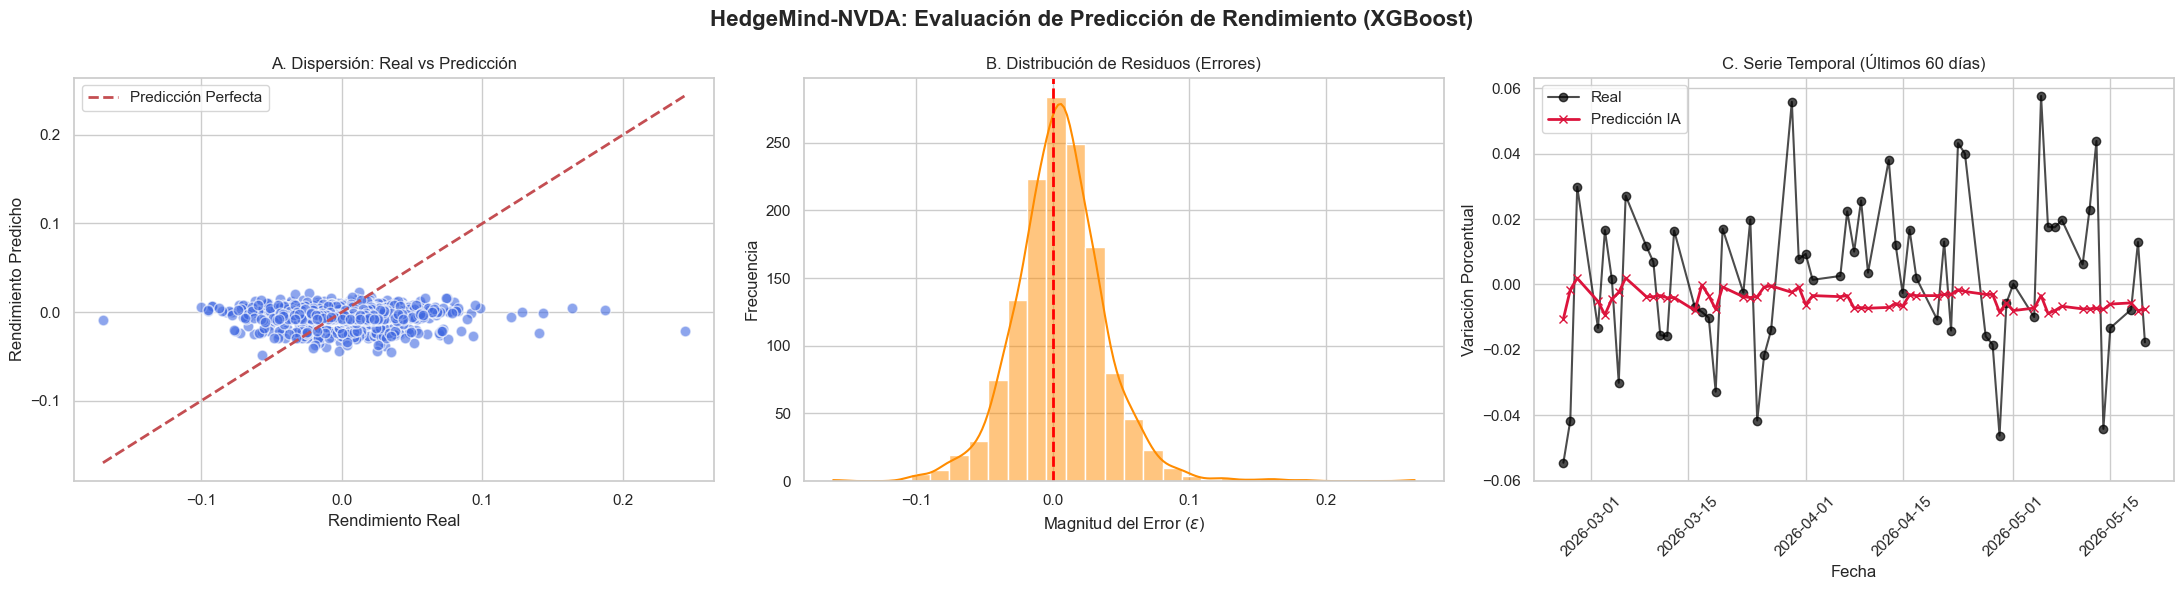

In [4]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('HedgeMind-NVDA: Evaluación de Predicción de Rendimiento (XGBoost)', fontsize=16, fontweight='bold')

# --- Gráfica A: Dispersión ---
axes[0].scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolors='w', s=60)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción Perfecta')
axes[0].set_title('A. Dispersión: Real vs Predicción')
axes[0].set_xlabel('Rendimiento Real')
axes[0].set_ylabel('Rendimiento Predicho')
axes[0].legend()

# --- Gráfica B: Histograma de Residuos ---
residuos = y_test - y_pred
sns.histplot(residuos, kde=True, ax=axes[1], color='darkorange', bins=30)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set_title('B. Distribución de Residuos (Errores)')
axes[1].set_xlabel('Magnitud del Error ($\epsilon$)')
axes[1].set_ylabel('Frecuencia')

# --- Gráfica C: Serie Temporal ---
dias = min(60, len(y_test)) 
axes[2].plot(fechas_test[-dias:], y_test.values[-dias:], label='Real', marker='o', color='black', alpha=0.7)
axes[2].plot(fechas_test[-dias:], y_pred[-dias:], label='Predicción IA', marker='x', color='crimson', lw=2)
axes[2].set_title('C. Serie Temporal (Últimos 60 días)')
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel('Variación Porcentual')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.savefig("graficas_hito3_hedgemind.png", dpi=300, bbox_inches='tight')
plt.show()